# Ground-Truth GRU: What Solution Does the Model Learn?

Companion to `main.ipynb` (which fits **human behavior**). Here the shared GRU is
trained directly on **ground truth** — the dataset's optimal actions and the
rewards those actions yield — and we inspect what solution it spontaneously
discovers:

1. Does it recover the optimal policy on held-out task designs, and how fast?
2. What does its hidden state encode? (PCA / tSNE / gates / value readouts)

**Pipeline**:

| Stage | Content |
|---|---|
| 1 | Environment & configuration |
| 2 | Design-level split (by task_number, not by session) |
| 3 | Build optimal trajectories (ground-truth targets) |
| 4 | Train: ground-truth GRU + human-fitted GRU (comparison) |
| 5 | Held-out recovery: P(best) adaptation curves |
| 6 | Dynamics: PCA / tSNE / gates / value probe |
| 7 | Summary & caveats |

Implementation: `utils.py` (shared pipeline) + `utils_ground_truth.py`
(optimal-trajectory helpers, kept in a separate module so the human-behavior
pipeline is untouched).


## 1. Environment & Configuration

Runtime: `iiccsss-rl` (jax + optax + pandas + scipy + matplotlib + tSNE-learn +
openTSNE). Increase the caps in `CONFIG` (or set to `None`) to scale up.


In [1]:
%load_ext autoreload
%autoreload 2
import os, time, warnings
warnings.filterwarnings("ignore")
# Use the Agg backend in headless settings (nbconvert / scripts); keep inline in Jupyter
import matplotlib as _mpl
if "inline" not in _mpl.get_backend().lower() and "agg" not in _mpl.get_backend().lower():
    _mpl.use("Agg")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba-cache")  # tSNE/numba JIT cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from DataManager import DataManager
import utils
import utils_ground_truth as ugt

CONFIG = {
    "data_dir": "data/OSF",
    "seed": 0,
    "train_frac": 0.7,
    "val_frac": 0.15,

    # GRU (both the ground-truth and the human-fitted comparison model)
    "hidden_size": 32,
    "learning_rate": 1e-3,
    "n_epochs": 32,
    "batch_size": 64,
    "max_gru_sessions": None,  # random subset of train-design sessions; None = all

    # Evaluation / dynamics
    "max_trials": 60,
    "max_probe_sessions": 80,
}

t0 = time.time()
DM = DataManager(data_dir=CONFIG["data_dir"], download_limit=0)
print(f"DataManager loaded in {time.time() - t0:.1f}s")


Local data found with 419 files. Skipping OSF download.
Formatting data for models...


100%|██████████| 419/419 [00:14<00:00, 29.26it/s]

DataManager loaded in 14.4s


## 2. Design-Level Split

Same convention as `main.ipynb`: split sessions by task **design** (`task_number`),
so the test set contains designs the model never saw during training. The val split
is used to watch GRU early stopping (it does not participate in fitting).


In [2]:
train_df, val_df, test_df, split_summary = utils.split_task_designs(
    DM, train_frac=CONFIG["train_frac"], val_frac=CONFIG["val_frac"], seed=CONFIG["seed"])
split_summary


,split,n_designs,n_sessions,n_trials
0,train,986,1238,246508
1,val,211,318,63371
2,test,212,534,106156


## 3. Optimal Trajectories: Training on Ground Truth

The dataset defines the optimal action for every trial: `best_actions` is the
per-state argmax of the mean arm outcomes. To train a GRU on ground truth we
replace the human history with an *optimal agent's* history:

- `actions[t] = best_actions[t]` (what an optimal chooser would do);
- `rewards[t] = arm_outcomes[t][best_actions[t]]` (the outcome that action would
  receive on that trial).

The model's job: given the rewards observed so far (from optimal choices), output
the optimal action. Since every session starts from `h₀ = 0`, on a held-out design
the model must figure out which arm is best from scratch — that is where the
"spontaneously learned solution" shows up.


In [3]:
opt_train_rows = ugt.optimal_rows([row for _, row in train_df.iterrows()])
opt_val_rows = ugt.optimal_rows([row for _, row in val_df.iterrows()])
opt_test_rows = ugt.optimal_rows([row for _, row in test_df.iterrows()])
print(f"optimal sessions: train={len(opt_train_rows)}, val={len(opt_val_rows)}, test={len(opt_test_rows)}")

# peek: first trials of one test session — human history vs the optimal history
example = opt_test_rows[0]
n = 10
pd.DataFrame({
    "trial": np.arange(1, n + 1),
    "state": example["states"][:n],
    "optimal_action": example["actions"][:n],
    "optimal_reward": example["rewards"][:n],
})


optimal sessions: train=1238, val=318, test=534


,trial,state,optimal_action,optimal_reward
0,1,0,2,58.0
1,2,1,1,0.0
2,3,1,1,0.0
3,4,0,2,59.0
4,5,0,2,58.0
5,6,1,1,0.0
6,7,1,1,0.0
7,8,0,2,56.0
8,9,0,2,0.0
9,10,1,1,17.0


## 4. Training

Two GRUs with identical architecture and hyperparameters:

1. **Ground-truth GRU** — trained on the optimal trajectories above;
2. **Human-fitted GRU** — trained on human choices (same as `main.ipynb`), as the
   comparison condition.


GRU fit complete. Mean NLL/trial: 0.3539
Ground-truth GRU trained on 1238 sessions in 20.5s


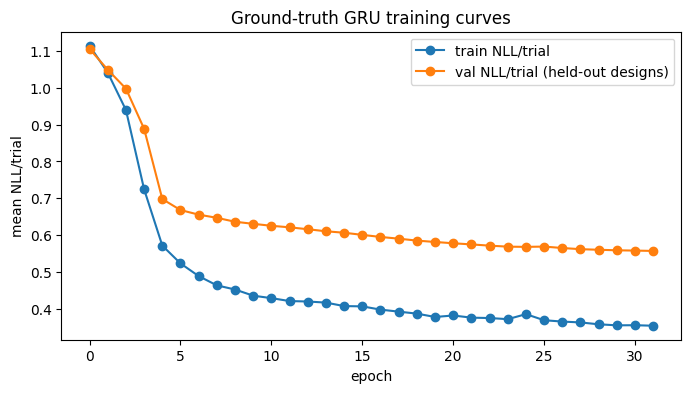

In [4]:
t0 = time.time()
gru_opt, gru_opt_used = ugt.train_gru_optimal(
    train_df, val_df,
    hidden_size=CONFIG["hidden_size"], learning_rate=CONFIG["learning_rate"],
    n_epochs=CONFIG["n_epochs"], batch_size=CONFIG["batch_size"],
    seed=CONFIG["seed"], max_sessions=CONFIG["max_gru_sessions"],
)
print(f"Ground-truth GRU trained on {len(gru_opt_used)} sessions in {time.time() - t0:.1f}s")

plt.figure(figsize=(8, 4))
plt.plot(gru_opt.loss_history, "-o", label="train NLL/trial")
plt.plot(gru_opt.test_loss_history, "-o", label="val NLL/trial (held-out designs)")
plt.xlabel("epoch")
plt.ylabel("mean NLL/trial")
plt.title("Ground-truth GRU training curves")
plt.legend()
plt.show()


In [5]:
t0 = time.time()
gru_human, gru_human_used = utils.train_gru(
    train_df, val_df,
    hidden_size=CONFIG["hidden_size"], learning_rate=CONFIG["learning_rate"],
    n_epochs=CONFIG["n_epochs"], batch_size=CONFIG["batch_size"],
    seed=CONFIG["seed"], max_sessions=CONFIG["max_gru_sessions"],
)
print(f"Human-fitted GRU trained on {len(gru_human_used)} sessions in {time.time() - t0:.1f}s")


GRU fit complete. Mean NLL/trial: 0.8037
Human-fitted GRU trained on 1238 sessions in 19.2s


In [ ]:
# Rescorla-Wagner (baseline)
t0 = time.time()
rw_model, rw_used = utils.fit_rw_pooled(train_df, seed=CONFIG["seed"], max_sessions=CONFIG["max_rw_sessions"])
print(f"RW fitted on {len(rw_used)} train sessions in {time.time() - t0:.1f}s")


## 5. Evaluation: Fit vs Recovery

Two different questions, two evaluation domains:

- **Fit (human trajectories, `test_rows`)** — how well does each model predict
  human choices on held-out designs? This is the metric used in `main.ipynb`;
  the human-fitted GRU evaluated here is directly comparable to that notebook
  (same code and split; results differ only if `CONFIG` differs).
- **Recovery (optimal trajectories, `opt_test_rows`)** — how quickly does each
  model assign probability to the optimal arm when fed an optimal agent's
  experience? This isolates "optimal-policy recovery" from "human-behavior fit".

The cross-table evaluates both models on both domains. The human-fitted GRU
never saw optimal trajectories during training (and the reward distributions
differ: human `points_won` vs optimal `arm_outcomes`), so its recovery panel is
a transfer check, not its native setting.

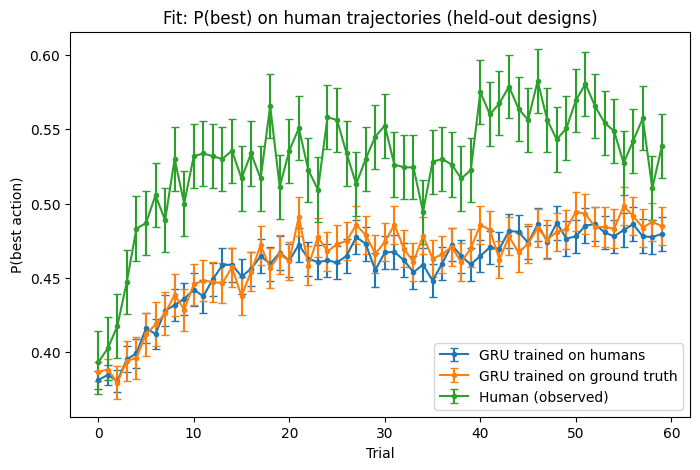

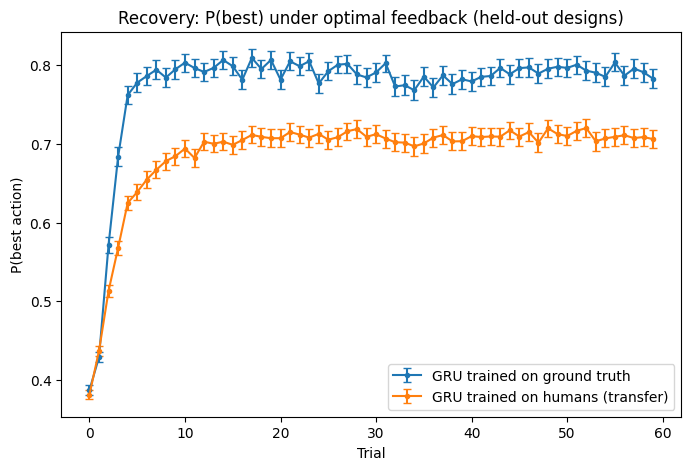

In [6]:
test_rows = [row for _, row in test_df.iterrows()]
human_curves = [utils.best_action_curve_from_observed_actions(r, CONFIG["max_trials"]) for r in test_rows]

# Cross-evaluation: both models x both trajectory types
eval_rows = []
for name, model in [("GRU (ground truth)", gru_opt), ("GRU (humans)", gru_human)]:
    for domain, rows in [("human trajectories", test_rows), ("optimal trajectories", opt_test_rows)]:
        m = utils.evaluate_model_on_sessions(model, rows)
        eval_rows.append({"model": name, "evaluation domain": domain, **m})
cross_eval = pd.DataFrame(eval_rows).round(4)
# cross_eval

# Fit: P(best) on human trajectories (native domain of the human-fitted model)
human_probs_gt = utils.replay_probs(gru_opt, test_rows)
human_probs_h = utils.replay_probs(gru_human, test_rows)
fit_curves = {
    "GRU trained on humans": utils.pull_average_learning_curve(
        [utils.best_action_prob_curve_from_probs(p, r, CONFIG["max_trials"]) for p, r in zip(human_probs_h, test_rows)],
        CONFIG["max_trials"]),
    "GRU trained on ground truth": utils.pull_average_learning_curve(
        [utils.best_action_prob_curve_from_probs(p, r, CONFIG["max_trials"]) for p, r in zip(human_probs_gt, test_rows)],
        CONFIG["max_trials"]),
    "Human (observed)": utils.pull_average_learning_curve(human_curves, CONFIG["max_trials"]),
}
utils.plot_learning_curves(
    fit_curves,
    title="Fit: P(best) on human trajectories (held-out designs)",
    ylabel="P(best action)",
    max_trials=CONFIG["max_trials"],
)
plt.show()

# Recovery: P(best) on optimal trajectories (native domain of the ground-truth model)
opt_probs_opt = utils.replay_probs(gru_opt, opt_test_rows)
opt_probs_human = utils.replay_probs(gru_human, opt_test_rows)
recovery_curves = {
    "GRU trained on ground truth": utils.pull_average_learning_curve(
        [utils.best_action_prob_curve_from_probs(p, r, CONFIG["max_trials"]) for p, r in zip(opt_probs_opt, opt_test_rows)],
        CONFIG["max_trials"]),
    "GRU trained on humans (transfer)": utils.pull_average_learning_curve(
        [utils.best_action_prob_curve_from_probs(p, r, CONFIG["max_trials"]) for p, r in zip(opt_probs_human, opt_test_rows)],
        CONFIG["max_trials"]),
}
utils.plot_learning_curves(
    recovery_curves,
    title="Recovery: P(best) under optimal feedback (held-out designs)",
    ylabel="P(best action)",
    max_trials=CONFIG["max_trials"],
)
plt.show()

## 6. Closed-Loop Evaluation: Can the Learned Policy Actually Play?

The teacher-forced P(best) above measures clone fidelity — what the model thinks
is best given a fixed (human or optimal) history. Here we let each model
actually play: starting from `h₀ = 0` on every held-out session, the model
samples its own actions, receives the reward those actions yield
(`arm_outcomes[t][chosen]`), and its own choices become the next input. This is
the online counterpart of replay — an early mistake now changes the feedback the
model sees (distribution shift), which the teacher-forced curves cannot capture.

We report per trial:

- **optimality rate** — fraction of episodes where the sampled action was the
  optimal one;
- **cumulative reward** — points accumulated along its own trajectory.

Both models play the same held-out designs (`n_episodes` seeded episodes per
session). This is the honest test of whether the learned policy is
self-sustaining, not just faithful under perfect feedback.

closed-loop episodes: 5 per model over 534 sessions


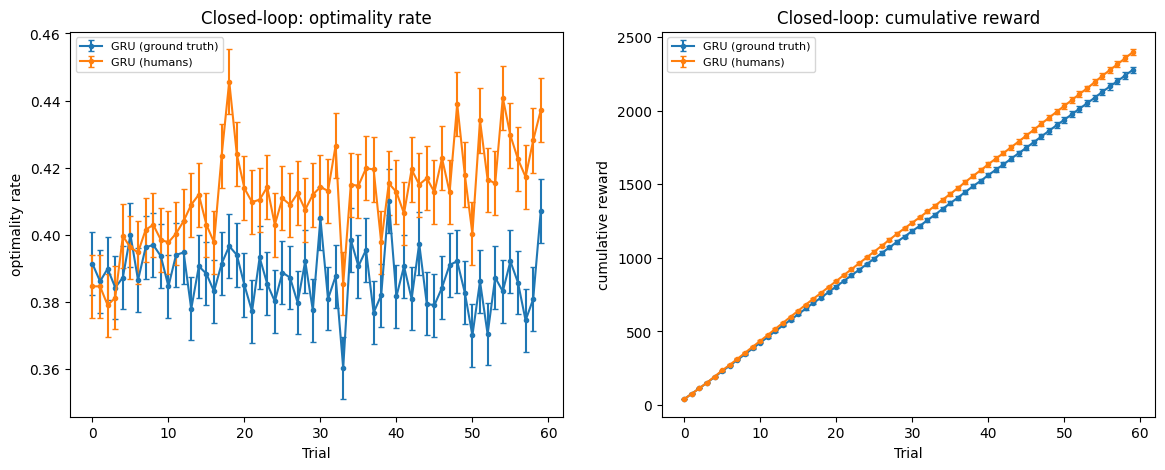

,optimality,final_reward
model,,
GRU (ground truth),0.387,2257.418
GRU (humans),0.411,2332.315


In [7]:
# Closed-loop: each model plays each held-out session from scratch, N episodes.
# (The row source only provides the environment — states/arm_outcomes — because
# the trajectory is self-generated; test_rows and opt_test_rows are equivalent here.)
n_episodes = 5

sim_gt = ugt.closed_loop_evaluate(gru_opt, test_rows, n_episodes=n_episodes,
                                  seed=CONFIG["seed"], max_trials=CONFIG["max_trials"])
sim_human = ugt.closed_loop_evaluate(gru_human, test_rows, n_episodes=n_episodes,
                                     seed=CONFIG["seed"], max_trials=CONFIG["max_trials"])
sim_df = pd.concat([
    sim_gt.assign(model="GRU (ground truth)"),
    sim_human.assign(model="GRU (humans)"),
], ignore_index=True)
print(f"closed-loop episodes: {sim_df['episode'].nunique()} per model over {sim_df['session_id'].nunique()} sessions")

def mean_curve(df, value_col):
    g = df.groupby(["model", "trial"])[value_col].agg(["mean", "std", "count"])
    g["se"] = g["std"] / np.sqrt(g["count"])
    return g.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, ylab in [(axes[0], "best_chosen", "optimality rate"),
                      (axes[1], "cum_reward", "cumulative reward")]:
    curve = mean_curve(sim_df, col)
    for model, grp in curve.groupby("model"):
        ax.errorbar(grp["trial"], grp["mean"], yerr=grp["se"],
                    fmt="-o", ms=3, capsize=2, label=model)
    ax.set_xlabel("Trial")
    ax.set_ylabel(ylab)
    ax.set_title(f"Closed-loop: {ylab}")
    ax.legend(fontsize=8)
plt.show()

# whole-session summary per model
summary = sim_df.groupby(["model", "session_id"]).agg(
    optimality=("best_chosen", "mean"),
    final_reward=("cum_reward", "last")).reset_index()
summary.groupby("model")[["optimality", "final_reward"]].mean().round(3)

## 7. What Solution Did It Discover?

We inspect the ground-truth GRU's latent space on the optimal test trajectories:

- **PCA / tSNE** — does the hidden state separate by task condition (e.g.
  visibility), or is the representation organized differently (e.g. by state or by
  estimated arm value)?
- **Gates** — how does the update gate (write rate) evolve over trials, and does it
  differ from the human-fitted model on the same optimal experience?
- **Value readout** — can a linear probe decode the EV of the best arm from `h_t`?
  If yes, the hidden state tracks values, i.e. the model learned a
  Q-value-like representation.


trials x columns: (106156, 115)
PCA explained variance (ground-truth GRU): [0.495 0.263]


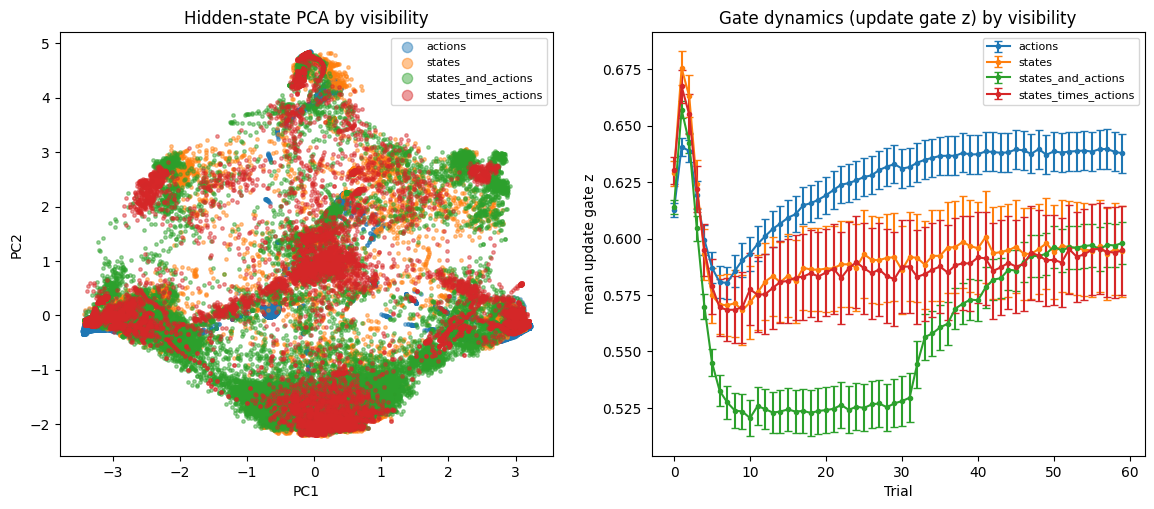

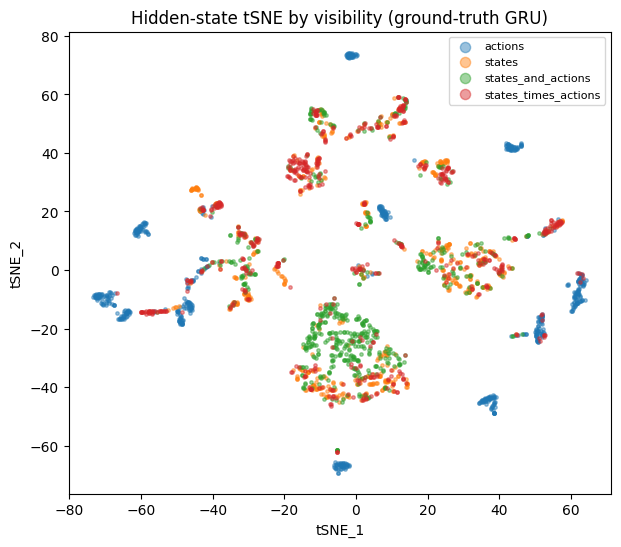

In [8]:
latent_opt = utils.collect_latents(gru_opt, opt_test_rows)
print("trials x columns:", latent_opt.shape)

Xh = latent_opt[utils.hidden_columns(latent_opt)].values
pca = utils.pca_scores(Xh, n_components=2)
latent_opt["PC1"], latent_opt["PC2"] = pca["scores"][:, 0], pca["scores"][:, 1]
print("PCA explained variance (ground-truth GRU):", pca["explained_var_ratio"].round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
utils.plot_pca_by_feature(latent_opt, "visibility", ax=axes[0])
utils.plot_gate_curves(latent_opt, gate="update", feature="visibility",
                       max_trials=CONFIG["max_trials"], ax=axes[1])
plt.show()

# Non-linear embedding (balanced subsample per visibility)
sub = utils.balanced_subset(latent_opt, by="visibility", n_per_group=600, seed=CONFIG["seed"])
Xsub = sub[utils.hidden_columns(latent_opt)].values
emb = utils.embed_2d(Xsub, method="tsne", seed=CONFIG["seed"])
sub = sub.copy()
sub["tSNE_1"], sub["tSNE_2"] = emb[:, 0], emb[:, 1]
utils.plot_scatter_by_feature(sub, "tSNE_1", "tSNE_2", "visibility",
                              title="Hidden-state tSNE by visibility (ground-truth GRU)")
plt.show()


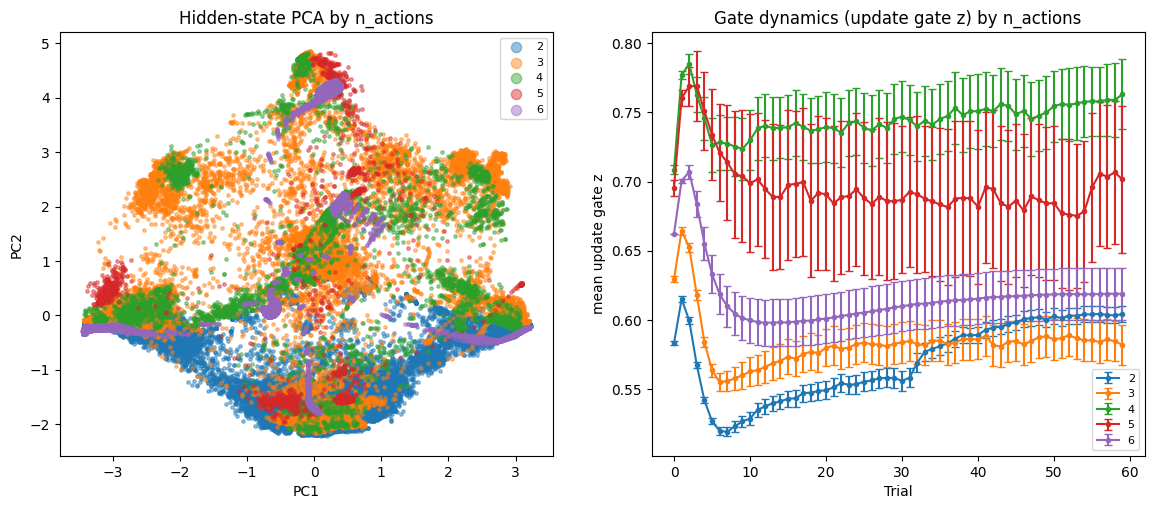

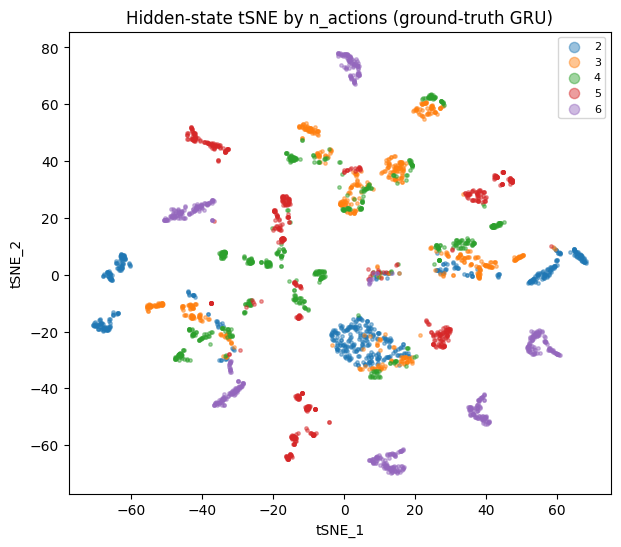

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
utils.plot_pca_by_feature(latent_opt, "n_actions", ax=axes[0])
utils.plot_gate_curves(latent_opt, gate="update", feature="n_actions",
                       max_trials=CONFIG["max_trials"], ax=axes[1])
plt.show()

# Non-linear embedding (balanced subsample per n_actions)
sub = utils.balanced_subset(latent_opt, by="n_actions", n_per_group=600, seed=CONFIG["seed"])
Xsub = sub[utils.hidden_columns(latent_opt)].values
emb = utils.embed_2d(Xsub, method="tsne", seed=CONFIG["seed"])
sub = sub.copy()
sub["tSNE_1"], sub["tSNE_2"] = emb[:, 0], emb[:, 1]
utils.plot_scatter_by_feature(sub, "tSNE_1", "tSNE_2", "n_actions",
                              title="Hidden-state tSNE by n_actions (ground-truth GRU)")
plt.show()

best-arm EV readout from h_t: train R2=0.253, val R2=0.070


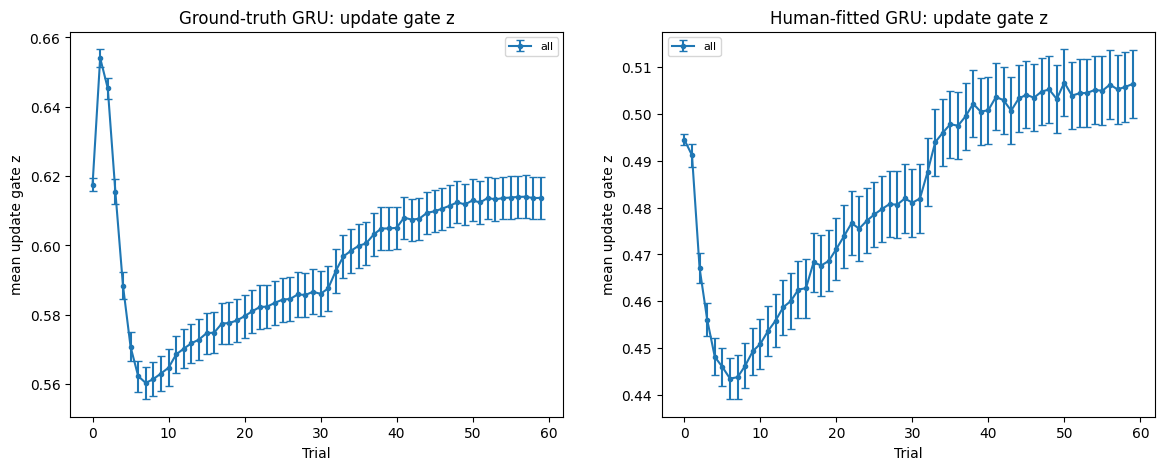

In [9]:
# Does h_t track the value of the best arm? (linear readout, session-level split)
y_ev = np.concatenate([ugt.best_action_ev(r) for r in opt_test_rows])
X_opt = latent_opt[utils.hidden_columns(latent_opt)].values
mask = ugt.session_split_mask(latent_opt["session_id"].values, 0.8, CONFIG["seed"])
ev_probe = ugt.train_linear_regression_probe(X_opt[mask], y_ev[mask], X_opt[~mask], y_ev[~mask])
print(f"best-arm EV readout from h_t: train R2={ev_probe['train_r2']:.3f}, val R2={ev_probe['val_r2']:.3f}")

# Compare gate dynamics on the same optimal trajectories: ground-truth vs human-fitted GRU
latent_opt_human = utils.collect_latents(gru_human, opt_test_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
utils.plot_gate_curves(latent_opt, gate="update", feature=None, max_trials=CONFIG["max_trials"],
                       title="Ground-truth GRU: update gate z", ax=axes[0])
utils.plot_gate_curves(latent_opt_human, gate="update", feature=None, max_trials=CONFIG["max_trials"],
                       title="Human-fitted GRU: update gate z", ax=axes[1])
plt.show()


## 8. Summary & Caveats

**What this notebook asks**: if the GRU is trained on ground truth instead of
human choices, what solution does it spontaneously discover?

- The model must infer the optimal arm from the rewards it observes (`h₀ = 0` on
  every held-out session), so its `P(best)` curve measures how quickly it recovers
  the optimal policy on designs it never saw.
- PCA / tSNE / gate curves / value readouts on the ground-truth model reveal what
  its hidden state encodes: does `h_t` track arm values? do gates behave like an
  adaptive learning rate? How does this differ from the human-fitted model?

**Caveats**

- `best_actions` is the dataset's convention (per-state argmax of the session-mean
  outcomes); for drifting tasks the "true" best arm varies over time, but this is
  the ground truth the dataset defines.
- The ground-truth GRU is trained teacher-forced on optimal histories: at run time
  it is only optimal if its own choices stay near-optimal. The analysis here is
  about representation (what it learned), not closed-loop performance.
- The human-fitted comparison model is trained on human choices; it shares no
  parameters with the ground-truth GRU (fresh instances, same seed initialization),
  so its numbers differ from `main.ipynb` only when `CONFIG` differs or when it is
  evaluated on optimal instead of human trajectories.
- tSNE/t-SNE are stochastic and subsampled; keep the seed fixed and re-run with
  larger `n_per_group` to confirm clusters.

- Closed-loop simulation samples actions (fixed seeds) and uses
  `arm_outcomes[t][chosen]` as the reward; optimality curves are averages over
  episodes, so conditions with few sessions are noisy.
